# DATA 2010 Project — Olympics (1896–2024)
**Notebook flow :**
1) Load data
2) Data types + variable types + granularity
3) Dataset inspection
4) Missing values + outliers 
5) Comprehensive facts
6) Cleaning
7) Feature engineering
8) Interesting facts + quick plots




## 1) Loading the data

In [4]:
### Imports + folders
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


In [5]:
### Load the CSV (update path)
path = r"C:\Users\joshu\Documents\Uni Work\Winter 2026\Data 2010\FInal Project\olympics_1896_2024.csv"

df_raw = pd.read_csv(path, low_memory=False)
print("Loaded shape (rows, cols):", df_raw.shape)

df = df_raw.copy()
df.head()


Loaded shape (rows, cols): (290697, 8)


,sex,age,team,year,season,sports,event,medal
0,M,72,Great Britain,1948,Summer,Art Competitions,"Art Competitions Mixed Sculpturing, Medals And...",NaN
1,M,72,Latvia,1936,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN
2,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Individual",NaN
3,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Team",NaN
4,M,72,Netherlands,1928,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN


## 2) Data types, variable types, and granularity

In [6]:
### 2A) Pandas data types + missing counts
dtype_table = pd.DataFrame({
    "column": df.columns,
    "pandas_dtype": [df[c].dtype for c in df.columns],
    "missing_count": [df[c].isna().sum() for c in df.columns]
}).sort_values("column")

dtype_table


,column,pandas_dtype,missing_count
1,age,int64,0
6,event,str,0
7,medal,str,247941
4,season,str,0
0,sex,str,0
5,sports,str,0
2,team,str,0
3,year,int64,0


In [7]:
### 2B) Variable type classification (Quantitative vs Qualitative Nominal/Ordinal)

def classify_variable(col_name: str):
    col = col_name.lower()

    if col in ["age", "age_imputed", "year", "medal_points"]:
        return "Quantitative"
    if col in ["decade", "age_group"]:
        return "Qualitative (Ordinal)"
    if col in ["name", "sex", "team", "noc", "season", "city", "sports", "event", "medal", "team_clean", "won_medal"]:
        return "Qualitative (Nominal)"

    if pd.api.types.is_numeric_dtype(df[col_name]):
        return "Quantitative"
    return "Qualitative (Nominal)"

var_type_table = pd.DataFrame({
    "column": df.columns,
    "pandas_dtype": [df[c].dtype for c in df.columns],
    "variable_type": [classify_variable(c) for c in df.columns]
}).sort_values(["variable_type", "column"])

var_type_table


,column,pandas_dtype,variable_type
6,event,str,Qualitative (Nominal)
7,medal,str,Qualitative (Nominal)
4,season,str,Qualitative (Nominal)
0,sex,str,Qualitative (Nominal)
5,sports,str,Qualitative (Nominal)
2,team,str,Qualitative (Nominal)
1,age,int64,Quantitative
3,year,int64,Quantitative


In [8]:
### 2C) Granularity (what one row represents)
### Proxy check: uniqueness of (name, year, event)

granularity_key = ["name", "year", "event"]
missing_g = [c for c in granularity_key if c not in df.columns]

if missing_g:
    print("Cannot verify granularity because missing:", missing_g)
else:
    total_rows = df.shape[0]
    unique_rows = df.drop_duplicates(granularity_key).shape[0]
    dup = total_rows - unique_rows

    print("Total rows:", total_rows)
    print("Unique rows by (name, year, event):", unique_rows)
    print("Duplicates under this key:", dup)

    print("\nInterpretation:")
    print("- Intended: one athlete entry in one event in one year.")
    print("- Duplicates can occur due to team events or repeated records.")


Cannot verify granularity because missing: ['name']


## 3) Dataset inspection

In [9]:
### Shape + columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Columns list:", df.columns.tolist())


Rows: 290697
Columns: 8
Columns list: ['sex', 'age', 'team', 'year', 'season', 'sports', 'event', 'medal']


In [10]:
### Sample rows
df.sample(5, random_state=42)


,sex,age,team,year,season,sports,event,medal
66319,M,29,Australia,1992,Summer,Water Polo,Water Polo Men's Water Polo,NaN
20453,M,35,South Africa,1960,Summer,Athletics,Athletics Men's 20 kilometres Walk,NaN
122438,M,26,Switzerland,1960,Winter,Cross Country Skiing,Cross Country Skiing Men's 15 kilometres,NaN
248248,M,20,Nigeria,1988,Summer,Boxing,Boxing Men's Bantamweight,NaN
224855,M,21,South Korea,2002,Winter,Speed Skating,"Speed Skating Men's 1,000 metres",NaN


In [11]:
### Numeric summary (if any numeric columns exist)
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
age,290697.0,25.684207,6.282759,10.0,22.0,25.0,29.0,72.0
year,290697.0,1984.278324,29.894844,1896.0,1968.0,1992.0,2008.0,2024.0


In [12]:
### Year range + unique years (year is already numeric in this dataset)
if "year" in df.columns:
    print("Year range:", df["year"].min(), "to", df["year"].max())
    print("Unique years:", df["year"].nunique())


Year range: 1896 to 2024
Unique years: 38


## 4) Missing values and outliers (only handle if needed)

In [13]:
### Missing values by column (top 15)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts.head(15)


medal     247941
sex            0
team           0
age            0
year           0
season         0
sports         0
event          0
dtype: int64

In [14]:
### Total missing values
total_missing = int(df.isna().sum().sum())
print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing values found. Skipping imputation.")


Total missing values: 247941


In [15]:
### Outlier check for age (flag only; do not delete)
if "age" in df.columns:
    print("Age range (raw):", df["age"].min(), "to", df["age"].max())
    suspicious = df["age"].notna() & ((df["age"] < 10) | (df["age"] > 75))
    print("Suspicious age rows:", int(suspicious.sum()))
else:
    print("No age column found.")


Age range (raw): 10 to 72
Suspicious age rows: 0


## 5) Comprehensive facts and inspections

In [16]:
### Quick facts (sex, medal, unique teams/sports/events, editions)
facts = {}

if "sex" in df.columns:
    facts["sex_counts"] = df["sex"].value_counts(dropna=False).to_dict()

if "medal" in df.columns:
    facts["medal_counts_top10"] = df["medal"].value_counts(dropna=False).head(10).to_dict()

for col in ["team", "sports", "event"]:
    if col in df.columns:
        facts[f"unique_{col}"] = int(df[col].nunique())

ed_cols = ["year", "season", "city"]
if all(c in df.columns for c in ed_cols):
    facts["editions_year_season_city"] = int(df.drop_duplicates(ed_cols).shape[0])

# Empty-string medal check
if "medal" in df.columns:
    facts["empty_string_medal_rows"] = int((df["medal"].astype(str).str.strip() == "").sum())

facts


{'sex_counts': {'M': 202596, 'F': 88101},
 'medal_counts_top10': {nan: 247941,
  'Gold': 14407,
  'Bronze': 14333,
  'Silver': 14016},
 'unique_team': 1151,
 'unique_sports': 92,
 'unique_event': 1534,
 'empty_string_medal_rows': 0}

## 6) Data cleaning (apply only if needed)

In [17]:
### 6A) Standardize sex values to M/F (safe if already M/F)
if "sex" in df.columns:
    before = df["sex"].value_counts(dropna=False)
    df["sex"] = df["sex"].astype(str).str.strip()
    df["sex"] = df["sex"].replace({
        "Male": "M", "male": "M", "m": "M",
        "Female": "F", "female": "F", "f": "F"
    })
    after = df["sex"].value_counts(dropna=False)

    print("Sex values before:\n", before.head(10))
    print("\nSex values after:\n", after.head(10))


Sex values before:
 sex
M    202596
F     88101
Name: count, dtype: int64

Sex values after:
 sex
M    202596
F     88101
Name: count, dtype: int64


In [18]:
### 6B) Remove exact duplicates (before/after)
dup_before = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
dup_after = int(df.duplicated().sum())

print("Duplicate rows before:", dup_before)
print("Duplicate rows after: ", dup_after)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows before: 35568
Duplicate rows after:  0
Shape after dropping duplicates: (255129, 8)


In [19]:
### 6C) Impute age ONLY if missing ages exist
if "age" in df.columns:
    missing_age_before = int(df["age"].isna().sum())
    print("Missing age before:", missing_age_before)

    if missing_age_before == 0:
        df["age_imputed"] = df["age"]
        print("No missing age. age_imputed equals age.")
    else:
        overall_median = df["age"].median()
        df["age_imputed"] = df["age"]
        group_median = df.groupby(["sex", "sports"])["age"].transform("median")
        df["age_imputed"] = df["age_imputed"].fillna(group_median)
        df["age_imputed"] = df["age_imputed"].fillna(overall_median)

        missing_age_after = int(df["age_imputed"].isna().sum())
        print("Missing age after (age_imputed):", missing_age_after)
else:
    print("No age column found.")


Missing age before: 0
No missing age. age_imputed equals age.


In [20]:
### 6D) Flag suspicious ages (outliers), do not remove
if "age_imputed" in df.columns:
    df["age_flag_suspicious"] = (df["age_imputed"] < 10) | (df["age_imputed"] > 75)
    print("Suspicious age rows:", int(df["age_flag_suspicious"].sum()))


Suspicious age rows: 0


In [22]:
# 6E-1) Start from a copy
country_df = df.copy()

# 6E-2) Remove numeric suffixes like India-1 -> India
country_df["team_clean"] = (
    country_df["team"]
    .str.replace(r"-\d+$", "", regex=True)
    .str.strip()
)

# 6E-3) Standardize historical / obsolete labels to present-day sovereign countries
country_df["team_clean"] = country_df["team_clean"].replace({
    "British India": "India",
    "East Germany": "Germany",
    "West Germany": "Germany",
    "Soviet Union": "Russia",
    "ROC": "Russia",
    "Russian Empire": "Russia",
    "Czechoslovakia": "Czech Republic",
    "Bohemia": "Czech Republic",
    "Yugoslavia": "Serbia",
    "Serbia and Montenegro": "Serbia",
    "United Arab Republic": "Egypt",
    "Great Britain": "United Kingdom"
})

# 6E-4) Keep only present-day sovereign countries
valid_current_countries = {
    "Afghanistan", "Albania", "Algeria", "Andorra", "Angola",
    "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria",
    "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh", "Barbados", "Belarus",
    "Belgium", "Belize", "Benin", "Bhutan", "Bolivia",
    "Bosnia and Herzegovina", "Botswana", "Brazil", "Brunei", "Bulgaria",
    "Burkina Faso", "Burundi", "Cambodia", "Cameroon", "Canada",
    "Cape Verde", "Central African Republic", "Chad", "Chile",
    "China", "Colombia", "Comoros", "Congo", "Costa Rica",
    "Croatia", "Cuba", "Cyprus", "Czech Republic", "Denmark", "Djibouti",
    "Dominica", "Dominican Republic", "Ecuador", "Egypt", "El Salvador",
    "Equatorial Guinea", "Eritrea", "Estonia", "Eswatini", "Ethiopia",
    "Fiji", "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany",
    "Ghana", "Greece", "Grenada", "Guatemala",
    "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras",
    "Hungary", "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland",
    "Israel", "Italy", "Ivory Coast", "Jamaica", "Japan", "Jordan",
    "Kazakhstan", "Kenya", "Kosovo", "Kuwait", "Kyrgyzstan", "Laos",
    "Latvia", "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein",
    "Lithuania", "Luxembourg", "Madagascar", "Malawi", "Malaysia", "Maldives",
    "Mali", "Malta", "Mauritania", "Mauritius", "Mexico", "Moldova",
    "Monaco", "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar",
    "Namibia", "Nepal", "Netherlands", "New Zealand", "Nicaragua", "Niger",
    "Nigeria", "North Korea", "North Macedonia", "Norway", "Oman", "Pakistan",
    "Panama", "Papua New Guinea", "Paraguay", "Peru",
    "Philippines", "Poland", "Portugal", "Qatar", "Romania",
    "Russia", "Rwanda", "Saint Kitts and Nevis", "Saint Lucia", "Samoa",
    "San Marino", "Sao Tome and Principe", "Saudi Arabia", "Senegal", "Serbia",
    "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia",
    "Somalia", "South Africa", "South Korea", "South Sudan", "Spain",
    "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria",
    "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tonga",
    "Trinidad and Tobago", "Tunisia", "Turkey", "Turkmenistan", "Uganda",
    "Ukraine", "United Arab Emirates", "United Kingdom", "United States",
    "Uruguay", "Uzbekistan", "Venezuela", "Vietnam",
    "Yemen", "Zambia", "Zimbabwe"
}

# 6E-5) Filter to sovereign countries only
country_df_final = country_df[
    country_df["team_clean"].isin(valid_current_countries)
].copy()

# 6E-6) Replace the team column
country_df_final["team"] = country_df_final["team_clean"]

# 6E-7) Verify result
print("Cleaned shape:", country_df_final.shape)
print("Unique countries after cleaning:", country_df_final["team"].nunique())

print("\nExample cleaned country labels:")
print(sorted(country_df_final["team"].dropna().unique())[:40])

print("\nTop 20 countries after cleaning:")
print(country_df_final["team"].value_counts().head(20))

print("\nExact India labels before cleaning:")
print(sorted(country_df.loc[
    country_df["team"].str.fullmatch(r"India(?:-\d+)?|British India", case=False, na=False),
    "team"
].unique()))

print("\nExact India labels after cleaning:")
print(sorted(country_df_final.loc[country_df_final["team"] == "India", "team"].unique()))

df = country_df_final

Cleaned shape: (246110, 11)
Unique countries after cleaning: 184

Example cleaned country labels:
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Costa Rica']

Top 20 countries after cleaning:
team
United States     16681
Germany           14396
France            10756
United Kingdom    10691
Russia            10042
Italy              9722
Canada             9057
Japan              8212
Australia          7566
Sweden             7368
Hungary            6042
Poland             5890
Czech Republic     5549
Switzerland        5534
Netherlands        5440
Chin

## 7) Feature engineering

In [23]:
### 7A) Decade
df["decade"] = (df["year"] // 10) * 10

### 7B) Won medal flag
df["won_medal"] = df["medal"].isin(["Gold", "Silver", "Bronze"]).astype(int)

### 7C) Medal points
points_map = {"Gold": 3, "Silver": 2, "Bronze": 1}
df["medal_points"] = df["medal"].map(points_map).fillna(0).astype(int)

df[["year","decade","medal","won_medal","medal_points"]].head()


,year,decade,medal,won_medal,medal_points
0,1948,1940,NaN,0,0
1,1936,1930,NaN,0,0
2,1936,1930,NaN,0,0
3,1936,1930,NaN,0,0
4,1928,1920,NaN,0,0


In [24]:
### 7D) Missing year info + gaps between min/max
missing_year_rows = int(df["year"].isna().sum())
print("Missing year rows:", missing_year_rows)

year_min, year_max = int(df["year"].min()), int(df["year"].max())
years_present = set(df["year"].dropna().unique())
missing_years_list = [y for y in range(year_min, year_max + 1) if y not in years_present]

print("Year min:", year_min, "| Year max:", year_max)
print("Missing years between min/max:", len(missing_years_list))
missing_years_list[:30]


Missing year rows: 0
Year min: 1896 | Year max: 2024
Missing years between min/max: 91


[1897,
 1898,
 1899,
 1901,
 1902,
 1903,
 1905,
 1907,
 1909,
 1910,
 1911,
 1913,
 1914,
 1915,
 1916,
 1917,
 1918,
 1919,
 1921,
 1922,
 1923,
 1925,
 1926,
 1927,
 1929,
 1930,
 1931,
 1933,
 1934,
 1935]

## 8) Interesting facts + key plots

In [25]:
### 8A) Sex proportions (table)
sex_counts = df["sex"].value_counts(dropna=False)
sex_prop = (sex_counts / sex_counts.sum() * 100).round(2)
pd.DataFrame({"count": sex_counts, "percent": sex_prop})


,count,percent
sex,,
M,170264,69.18
F,75846,30.82


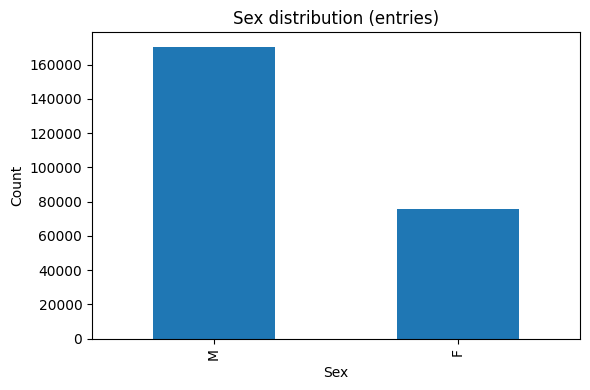

In [26]:
### Plot: Sex distribution
plt.figure(figsize=(6,4))
sex_counts.plot(kind="bar")
plt.title("Sex distribution (entries)")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/sex_distribution.png", dpi=300)
plt.show()


In [27]:
### 8B) Age group distribution (requires age_imputed)
if "age_imputed" in df.columns:
    bins = [0, 15, 18, 25, 30, 35, 40, 50, 100]
    labels = ["<16", "16-18", "19-25", "26-30", "31-35", "36-40", "41-50", "51+"]

    df["age_group"] = pd.cut(df["age_imputed"], bins=bins, labels=labels, right=True)
    counts = df["age_group"].value_counts(dropna=False).sort_index()
    perc = (counts / counts.sum() * 100).round(2)
    pd.DataFrame({"count": counts, "percent": perc})
else:
    print("age_imputed not available.")


In [28]:
### 8C) Medal counts by country (team)
medalists = df[df["medal"].isin(["Gold","Silver","Bronze"])].copy()
country_medals = medalists.groupby("team").size().sort_values(ascending=False)

print("Top 10 countries by medalist entries:")
print(country_medals.head(10))


Top 10 countries by medalist entries:
team
United States     4807
Russia            3253
Germany           3234
United Kingdom    1683
France            1572
Italy             1476
Sweden            1231
Australia         1224
Canada            1124
China             1049
dtype: int64


In [29]:
### Countries with exactly 1 medalist entry
one_medal = country_medals[country_medals == 1]
print("Countries with exactly 1 medalist entry:", one_medal.shape[0])
one_medal.head(20)


Countries with exactly 1 medalist entry: 22


team
Andorra                   1
Bolivia                   1
Bosnia and Herzegovina    1
Barbados                  1
Dominica                  1
Eritrea                   1
Ivory Coast               1
Gabon                     1
Guyana                    1
Haiti                     1
Burkina Faso              1
Djibouti                  1
Monaco                    1
Mauritius                 1
Senegal                   1
Saint Lucia               1
Niger                     1
North Macedonia           1
Togo                      1
Sudan                     1
dtype: int64

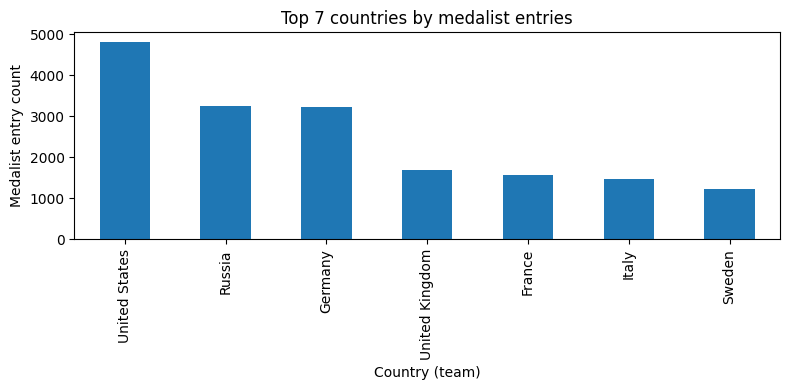

In [30]:
### Plot: Top 7 countries by medalist entries
top7 = country_medals.head(7)

plt.figure(figsize=(8,4))
top7.plot(kind="bar")
plt.title("Top 7 countries by medalist entries")
plt.xlabel("Country (team)")
plt.ylabel("Medalist entry count")
plt.tight_layout()
plt.savefig("figures/top7_countries_medals.png", dpi=300)
plt.show()


In [31]:
### Top 10 countries by medal type (Gold/Silver/Bronze) + one summary table
gold = medalists[medalists["medal"]=="Gold"].groupby("team").size().sort_values(ascending=False).head(10)
silver = medalists[medalists["medal"]=="Silver"].groupby("team").size().sort_values(ascending=False).head(10)
bronze = medalists[medalists["medal"]=="Bronze"].groupby("team").size().sort_values(ascending=False).head(10)

pd.DataFrame({"Gold": gold, "Silver": silver, "Bronze": bronze}).fillna(0).astype(int)


,Gold,Silver,Bronze
team,,,
Australia,0,406,488
Canada,364,365,395
China,399,354,0
France,479,508,585
Germany,1114,1043,1077
Hungary,372,0,360
Italy,509,484,483
Russia,1265,1023,965
Sweden,369,427,435


# Research Question 1
## Demographics and medal outcomes: age groups, sex, parity trends, and peak-age patterns

**Main question:**
**How do medal out-comes vary by age group and sex across sports, and which sports show the largest changes in gender parity and peak-age patterns across decades?**

We split Research quesion into three focused sub-questions so each is supported by clear plots:
- **RQ1(a):** How do medal outcomes vary by **age group** and **sex**?
- **RQ1(b):** Which decades show the **largest changes in gender parity** (male vs female shares)?
- **RQ1(c):** How do **peak-age patterns** change across decades (median + IQR of medalist ages)?

Run the cells in order.


### RQ1-1: Import libraries + folders

In [32]:
# RQ1-1) Imports(run once)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)


### RQ1-2: Standardize column names + create helper columns

In [33]:
# RQ1-2) Standardize column names + check required columns + create decade + pick age column
df_clean = df.copy()
# 1) Standardize column names (safe even if already standardized)
df_clean.columns = [c.strip().lower().replace(" ", "_") for c in df_clean.columns]

# 2) Check required columns exist (IMPORTANT: usually it's "sport", not "sports")
required = ["year", "sex", "sports", "medal"]

missing = [c for c in required if c not in df_clean.columns]

if not missing:
    print("There are no missing required columns.")
else:
    print("Missing required columns:", missing)

# 3) Create decade column (for decade-level trend analysis)
df_clean["decade"] = (df_clean["year"] // 10) * 10

# 4) Choose which age column to use (prefer imputed age if available)
if "age_imputed" in df_clean.columns:
    age_col = "age_imputed"
elif "age" in df_clean.columns:
    age_col = "age"
else:
    age_col = None

print("Using age column:", age_col)



There are no missing required columns.
Using age column: age_imputed


### RQ1-3: Create age groups (Olympics-style bins for convenient interpretation)

In [34]:
# RQ1-3) Create age groups 
age_order = ["<16", "16-18", "19-25", "26-30", "31-35", "36-40", "41-50", "51+"]

if "age_group" not in df_clean.columns:
    if age_col is None:
        print("No age column available.")
    else:
        bins = [0, 15, 18, 25, 30, 35, 40, 50, 100]
        df_clean["age_group"] = pd.cut(df_clean[age_col], bins=bins, labels=age_order, right=True)

# Force consistent category order for plotting
if "age_group" in df_clean.columns:
    df_clean["age_group"] = pd.Categorical(df_clean["age_group"], categories=age_order, ordered=True)

print(df_clean["age_group"].value_counts(dropna=False).sort_index())


age_group
<16        2757
16-18     15509
19-25    118261
26-30     67035
31-35     27096
36-40      8960
41-50      5163
51+        1329
Name: count, dtype: int64


### RQ1-4: Create medalists subset (Gold/Silver/Bronze only)

In [35]:
# RQ1-4) Create a "medalists" subset
# Purpose: keep ONLY rows where the athlete won a medal (Gold/Silver/Bronze).
# This is useful for analyses that focus on medal outcomes (not participation without medals).

medalists = df_clean[df_clean["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

# Print the shape (rows, columns) so you know how big the medalist-only dataset is.
print("Medalist rows (rows, cols):", medalists.shape)

Medalist rows (rows, cols): (34644, 15)


## RQ1a Plot 1 — 100% stacked bar: medalist sex composition by age group
### 1) What this shows:
###   For each age group, this chart displays the percentage of medal-winning entries
###  that are Female (F) vs Male (M). Each bar sums to 100%.
### 2) Why we use it:
###  A normal count-based stacked bar can hide smaller groups (e.g., 41+ females) because
### some age groups have many more medalists overall. Using percentages makes the
### M vs F comparison fair and easy across all age groups.

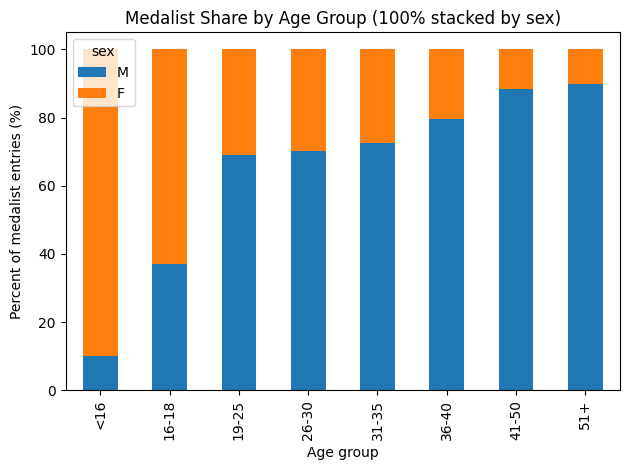

In [36]:
tab = (
    medalists.groupby(["age_group", "sex"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both sex columns exist (prevents errors if one category is missing)
for s in ["M", "F"]:
    if s not in tab.columns:
        tab[s] = 0

# Keep the age groups in the correct order
tab = tab[["M", "F"]].reindex(age_order)

# Convert counts to percentages within each age group
prop = tab.div(tab.sum(axis=1), axis=0) * 100

ax = prop.plot(kind="bar", stacked=True)
ax.set_title("Medalist Share by Age Group (100% stacked by sex)")
ax.set_xlabel("Age group")
ax.set_ylabel("Percent of medalist entries (%)")
plt.tight_layout()
plt.savefig("figures/RQ1a_plot1_100pct_stacked_agegroup_sex.png", dpi=300)
plt.show()

In [37]:
### Interpretation (RQ1a Plot 1: 100% stacked sex share by age group)
### What it means:
### - Each bar = one age group.
### - The bar shows the percentage of medalist entries that are Female vs Male in that age group.
### - This lets us compare sex balance across age groups fairly (even when some age groups are small).
###
### Key takeaway:
### - Identify age groups where female representation among medalists is higher/lower.
###
### What surprised us:
### - If very young (<16) or older (41+, 51+) groups are heavily skewed, it suggests certain sports/eras
###   produce medalists that are mostly one sex at those ages.
###
### Limitations:
### - This is medalist entries only, not all athletes.
### - Team events can inflate medalist entries (multiple athletes for one medal).
### - Age is imputed for some rows (age_imputed), which can slightly smooth real variation.

# Quick numeric summary 
prop_summary = prop.copy()
prop_summary["Female_minus_Male"] = prop_summary["F"] - prop_summary["M"]
prop_summary.sort_values("Female_minus_Male", ascending=False).head(3)

prop_summary.sort_values("Female_minus_Male").head(3)

sex,M,F,Female_minus_Male
age_group,,,
51+,89.940828,10.059172,-79.881657
41-50,88.268956,11.731044,-76.537911
36-40,79.701023,20.298977,-59.402046


## RQ1a Plot 2 — 100% stacked bar: medal type composition by age group
### 1) What this shows:
### For each age group, this chart shows the percentage breakdown of medal outcomes
### (Gold vs Silver vs Bronze) among medal-winning entries. Each bar sums to 100%.
### 2) Why we use it:
### Total medal counts can vary a lot across age groups. Using shares lets us compare
### whether some age groups tend to win a higher proportion of Gold (or Bronze, etc.)
### relative to other age groups.

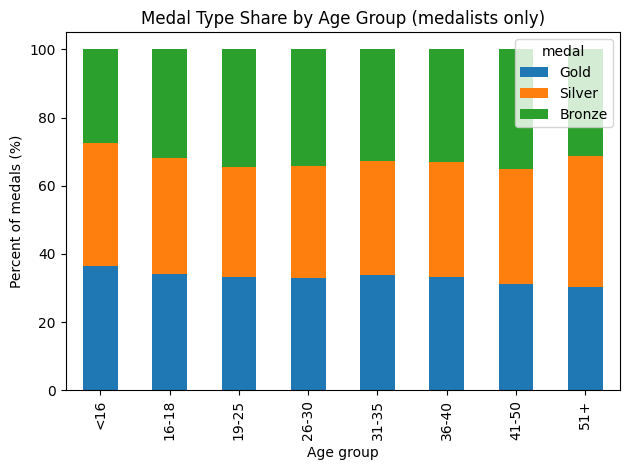

In [38]:
medal_tab = (
    medalists.groupby(["age_group", "medal"])
    .size()
    .unstack(fill_value=0)
)

# Ensure all medal categories exist (prevents KeyErrors if one is missing)
for m in ["Gold", "Silver", "Bronze"]:
    if m not in medal_tab.columns:
        medal_tab[m] = 0

# Keep a consistent medal order + age group order
medal_tab = medal_tab[["Gold", "Silver", "Bronze"]].reindex(age_order)

# Convert counts to percentages within each age group
medal_share = medal_tab.div(medal_tab.sum(axis=1), axis=0) * 100

ax = medal_share.plot(kind="bar", stacked=True)
ax.set_title("Medal Type Share by Age Group (medalists only)")
ax.set_xlabel("Age group")
ax.set_ylabel("Percent of medals (%)")
plt.tight_layout()
plt.savefig("figures/RQ1a_plot2_medal_type_share_by_agegroup.png", dpi=300)
plt.show()


In [39]:
### Interpretation (RQ1a Plot 2: medal type share by age group)
### What it means:
### - Each bar = one age group, and it sums to 100%.
### - The colors show how medals in that age group split into Gold vs Silver vs Bronze.
### - This helps check if some age groups have relatively more Gold (or Bronze), not just more medals.
###
### Key takeaway:
### - If Gold share is higher in certain age groups, that age range may align with peak performance.
###
### What surprised us:
### - If the Gold/Silver/Bronze shares look nearly constant across age groups, it suggests age affects
###   "how many medals happen" more than "which medal type happens."
###
### Limitations:
### - Medal type shares do NOT show the total number of medals (a small age group can still be 100%).
### - This is not causal: age does not "cause" medal type; sport, era, and competition depth matter.

# Quick numeric check: which age group has highest Gold share?
gold_by_age = medal_share["Gold"].sort_values(ascending=False)
gold_by_age.head(3), gold_by_age.tail(3)

(age_group
 <16      36.328125
 16-18    34.268930
 31-35    33.750602
 Name: Gold, dtype: float64,
 age_group
 26-30    32.829539
 41-50    31.044349
 51+      30.177515
 Name: Gold, dtype: float64)

# RQ1b Plot 3 — Gender parity over decades (male + female share on the same chart)
### 1) What this shows:
### This plot tracks how the share of Olympic entries changes over time for Female (F) and Male (M)
### athletes. Values are computed within each decade, so the lines represent long-term trends.
### 2) How to interpret:
### - A value of 0.50 means perfect parity (equal female and male representation).
### - As the female share rises toward 0.50, the Olympics become more gender-balanced.
### 3) Why we use decades:
### Using decades smooths out year-to-year noise and makes the overall trend easier to see.

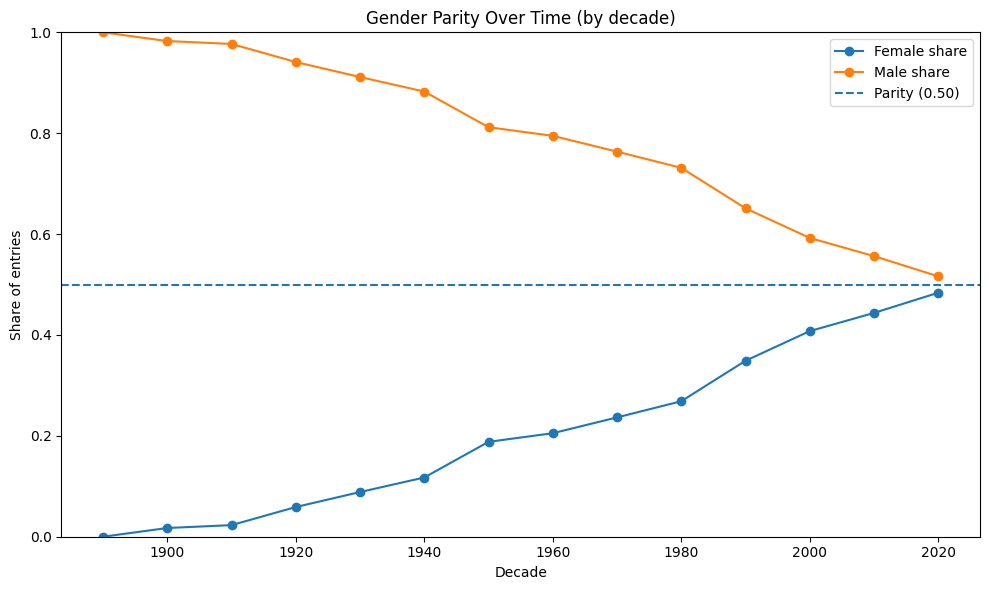

In [40]:
tmp = df_clean.dropna(subset=["decade", "sex"]).copy()

# Count entries by decade and sex
parity = (
    tmp.groupby(["decade", "sex"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both categories exist (prevents errors if a decade has only one sex)
for s in ["M", "F"]:
    if s not in parity.columns:
        parity[s] = 0

# Convert counts to shares within each decade
parity["female_share"] = parity["F"] / (parity["F"] + parity["M"])
parity["male_share"]   = parity["M"] / (parity["F"] + parity["M"])

plt.figure(figsize=(10,6))
plt.plot(parity.index, parity["female_share"], marker="o", label="Female share")
plt.plot(parity.index, parity["male_share"], marker="o", label="Male share")
plt.axhline(0.5, linestyle="--", label="Parity (0.50)")

plt.title("Gender Parity Over Time (by decade)")
plt.xlabel("Decade")
plt.ylabel("Share of entries")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("figures/RQ1b_plot3_gender_parity_by_decade.png", dpi=300)
plt.show()

In [41]:
### Interpretation (RQ1b Plot 3: gender parity over decades)
### What it means:
### - Each point is a decade.
### - Female share shows what fraction of entries are female in that decade.
### - Male share is the remainder (1 - female share).
### - The dashed 0.50 line is perfect parity.
###
### Key takeaway:
### - The long-term trend shows whether Olympics move toward gender balance over time.
###
### What surprised us:
### - If there are decades with plateaus or temporary reversals, it may reflect historical events,
###   changes in included events, or reporting/coverage differences.
###
### Limitations:
### - This measures participation entries, not medals.
### - Dataset composition (Summer/Winter mix, missing years, etc.) can affect the curve.
### - It does not explain why parity changes; it only shows the pattern.

# Quick summary: female share first decade vs last decade
female_start = parity["female_share"].dropna().iloc[0]
female_end = parity["female_share"].dropna().iloc[-1]
print("Female share: first decade =", round(float(female_start), 3), "| last decade =", round(float(female_end), 3))
print("Change (last - first) =", round(float(female_end - female_start), 3))

Female share: first decade = 0.0 | last decade = 0.484
Change (last - first) = 0.484


### RQ1b Plot 4 — Largest decade-to-decade changes in female participation share
### 1) What this shows:
### This plot measures how much the female participation share changes from one decade to the next.
### We use the absolute value so we focus on the size of the change (largest shifts), not direction.
### - The size of the shift in female representation between consecutive decades
### - Peaks highlight decades with the biggest parity changes
###
### 2) How to interpret:
### - Higher points indicate decades where gender representation shifted the most.
### - These decades contributed most to movement toward (or away from) parity.
###
### 3) Why this plot:
### - Female share is the standard way to report gender parity.
### - Male share is redundant because male_share = 1 - female_share, so the change plot is identical.


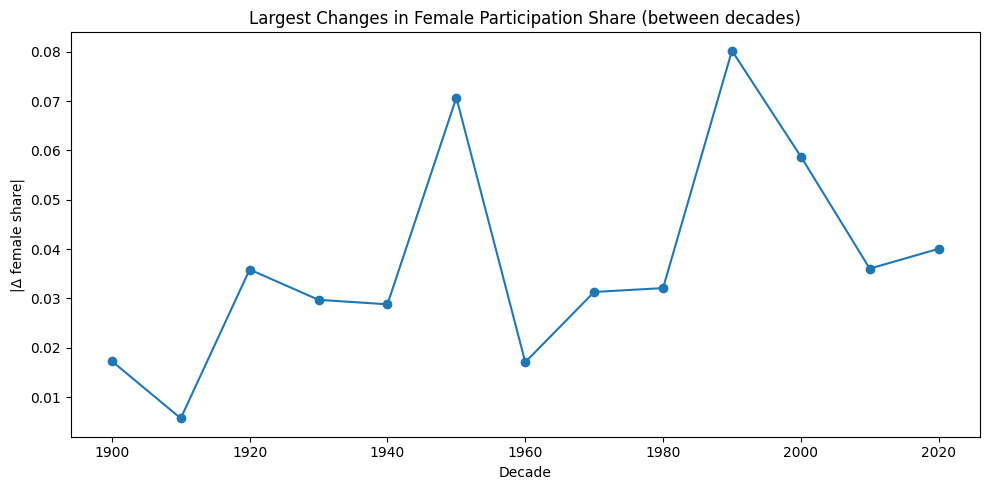

decade
1990    0.080231
1950    0.070720
2000    0.058777
2020    0.040069
2010    0.036048
Name: female_share, dtype: float64

In [42]:
# Absolute change in female share between consecutive decades
parity_change_f = parity["female_share"].diff().abs()

plt.figure(figsize=(10,5))
plt.plot(parity_change_f.index, parity_change_f.values, marker="o")
plt.title("Largest Changes in Female Participation Share (between decades)")
plt.xlabel("Decade")
plt.ylabel("|Δ female share|")
plt.tight_layout()
plt.savefig("figures/RQ1b_plot4_abs_change_female_share.png", dpi=300)
plt.show()

# Top 5 decades with the largest changes (table for reporting)
top5_f = parity_change_f.sort_values(ascending=False).head(5)
top5_f

In [43]:
### Interpretation (RQ1b Plot 4: largest changes in female participation share)
### What it means:
### - Each point measures how much female share changed from the previous decade.
### - We use absolute change |Δ| so we highlight the biggest shifts, regardless of direction.
###
### Key takeaway:
### - Peaks identify the decades where gender representation changed the most.
### - These are the key “transition periods” in gender inclusion.
###
### What surprised us:
### - If the biggest jumps cluster in a certain era, it suggests policy/event expansion effects.
###
### Limitations:
### - Changes can be affected by which editions are present in the dataset for a decade.
### - This is participation share, not medal share.
### - Male change is identical in magnitude (male_share = 1 - female_share), so we only report female.

# Report-friendly: show the top 5 decades with biggest shifts
top5_f

decade
1990    0.080231
1950    0.070720
2000    0.058777
2020    0.040069
2010    0.036048
Name: female_share, dtype: float64

### RQ1c (ONE PLOT): Peak-age patterns across decades using ALL sports together
### Plot: Median + IQR of medalist ages by decade (Female vs Male)
###
### Research goal (simple):
### Instead of choosing one sport, we combine medalists from ALL sports to get one overall view of
### how the “typical” medalist age changes across decades for females and males.
###
### Key terms (definitions):
### 1) Medalist:
###    - A row is a medalist if medal ∈ {Gold, Silver, Bronze}.
### 2) Decade:
###    - We group years into decades (example: 1992 → 1990s) to smooth long-term trends.
### 3) Median age:
###    - The middle value after sorting ages (robust to outliers).
###    - Used as a proxy for the “typical” (peak) medal-winning age in that decade.
### 4) IQR (Interquartile Range):
###    - Q1 = 25th percentile, Q3 = 75th percentile.
###    - The shaded band (Q1 to Q3) shows the typical spread (middle 50%) of medalist ages.
###
### What this plot shows:
### - Female and male median medalist age by decade (lines)
### - Female and male IQR bands by decade (shading)
###
### Why this approach:
### - It avoids cherry-picking a single sport.
### - It provides one clean plot you can include in the report.


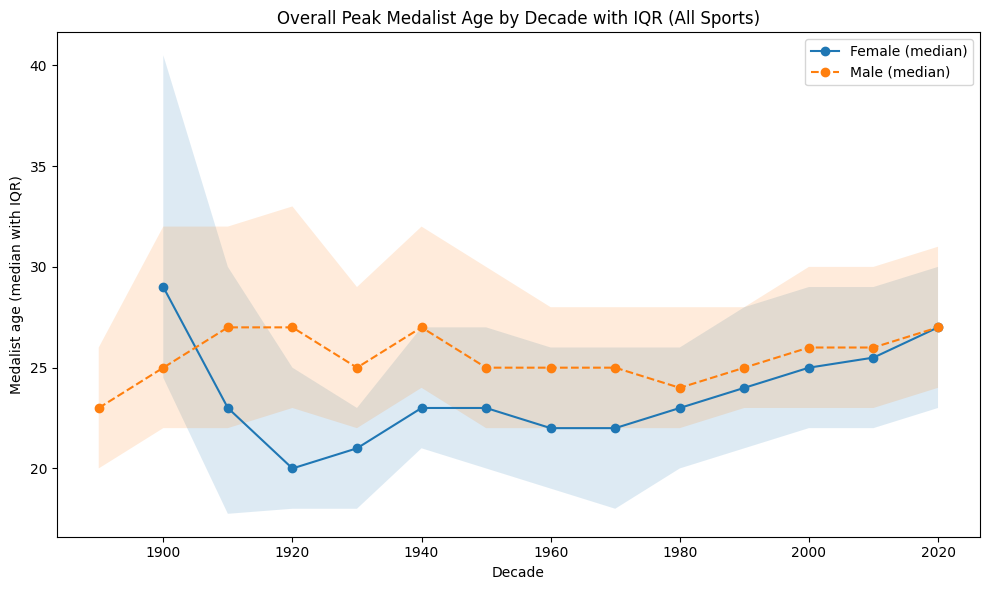

In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Step 0) Check that we have an age column available
if age_col is None:
    print("No age column available for peak-age analysis.")
else:
    # Step 1) Keep only medalist rows with valid ages (drop missing ages)
    medalists_age = medalists.dropna(subset=[age_col]).copy()

    # Step 2) Helper function: compute median + IQR by decade for one sex (ALL sports combined)
    def decade_quantiles(df, sex_value):
        sub = df[df["sex"] == sex_value]
        g = sub.groupby("decade")[age_col]
        out = pd.DataFrame({
            "median": g.median(),
            "q25": g.quantile(0.25),
            "q75": g.quantile(0.75),
            "n": g.size()
        }).reset_index().sort_values("decade")
        return out

    # Step 3) Compute decade summaries for females and males
    F = decade_quantiles(medalists_age, "F")
    M = decade_quantiles(medalists_age, "M")

    # Step 4) Plot median lines + IQR bands
    plt.figure(figsize=(10, 6))

    if len(F) > 0:
        plt.fill_between(F["decade"], F["q25"], F["q75"], alpha=0.15)
        plt.plot(F["decade"], F["median"], marker="o", label="Female (median)")

    if len(M) > 0:
        plt.fill_between(M["decade"], M["q25"], M["q75"], alpha=0.15)
        plt.plot(M["decade"], M["median"], marker="o", linestyle="--", label="Male (median)")

    plt.title("Overall Peak Medalist Age by Decade with IQR (All Sports)")
    plt.xlabel("Decade")
    plt.ylabel("Medalist age (median with IQR)")
    plt.legend()
    plt.tight_layout()

    # Step 5) Save figure for Overleaf
    plt.savefig("figures/plot5.png", dpi=300)
    plt.show()

    # Step 6) (Optional) Show sample size per decade for reporting
    # This table helps explain which decades have more/less data.
    F[["decade", "n"]].rename(columns={"n": "female_n"}).merge(
        M[["decade", "n"]].rename(columns={"n": "male_n"}),
        on="decade",
        how="outer"
    ).fillna(0).astype({"female_n": int, "male_n": int})

In [45]:
### Interpretation (RQ1c Plot 5: overall peak medalist age by decade with IQR, all sports)
### What it means:
### - The solid/dashed lines show the typical (median) medalist age for females and males by decade.
### - The shaded area is the IQR (middle 50% of medalist ages), showing how spread out ages are.
### - Because we combine all sports, this gives one clean “overall Olympics” age pattern.
###
### Key takeaway:
### - If the median age rises, it suggests medal-winning ages are getting older over time.
### - If the IQR widens, it suggests a broader range of ages win medals in that era.
###
### What surprised us:
### - Early decades may show unstable patterns due to very low female participation (small sample size).
### - Some decades might show sudden shifts due to changes in Olympic participation or event structure.
###
### Limitations:
### - Combining all sports hides sport-specific peak ages (gymnastics vs rowing differ a lot).
### - Team events can inflate medalist rows.
### - Age imputation can smooth the trend slightly.
### - Early decades for women may be less reliable if female sample size is small.

# Simple numeric summary: female vs male overall median (all decades pooled)
overall_f_med = medalists_age[medalists_age["sex"]=="F"][age_col].median()
overall_m_med = medalists_age[medalists_age["sex"]=="M"][age_col].median()
print("Overall median medalist age (Female):", round(float(overall_f_med), 2))
print("Overall median medalist age (Male):  ", round(float(overall_m_med), 2))

Overall median medalist age (Female): 25.0
Overall median medalist age (Male):   26.0


### RQ1-5 Export summary tables used in RQ1

In [46]:
### Optional: Export small tables for the report appendix (RQ1)

import os
os.makedirs("outputs", exist_ok=True)

# 1) Export gender-parity-by-decade table (used in RQ1b plots)
if "parity" in locals():
    parity.reset_index().to_csv("outputs/rq1_parity_by_decade.csv", index=False)
    print("Saved: outputs/rq1_parity_by_decade.csv")
else:
    print("Skip parity export: 'parity' not found (run RQ1b Plot 3 first).")

# 2) Export peak-age (median + IQR) by decade (ALL sports combined, used in RQ1c Plot 5)
# This requires that RQ1c created F and M tables in the current session.
if all(x in locals() for x in ["F", "M"]) and (age_col is not None):
    peak_export = pd.concat(
        [
            F.assign(sex="F"),
            M.assign(sex="M")
        ],
        ignore_index=True
    )
    peak_export.to_csv("outputs/rq1_peak_age_iqr_by_decade_all_sports.csv", index=False)
    print("Saved: outputs/rq1_peak_age_iqr_by_decade_all_sports.csv")
else:
    print("Skip peak-age export: F/M tables not found or age_col is None (run RQ1c Plot 5 first).")

Saved: outputs/rq1_parity_by_decade.csv
Skip peak-age export: F/M tables not found or age_col is None (run RQ1c Plot 5 first).


# Research Question 2
## Country participation size, medals, efficiency, and Olympic dominance

**Main question:**
**To what extent is the number of athletes a country sends associated with its total medal count, and how does this relationship shape dominance in a given Olympic year?**

### Sub-questions
- **SQA (Correlation):** Is there a positive relationship between the number of athletes a country sends and the number of medals it wins?
- **SQB (Efficiency):** Which countries are the most efficient at converting athlete participation into medals?
- **SQC (Dominance):** Which countries dominate the Olympic Games in a given year, and is this dominance primarily driven by delegation size or efficiency?

> **Important data note:** this dataset does not include a unique athlete identifier. Because of that, this section uses **country-year participation size** as a proxy for delegation size, measured by the number of athlete-event rows for each country in a given Olympic year.


## SQA (Correlation): Is there a positive relationship between the number of athletes a country sends and the number of medals it wins?

Because this dataset does not include an athlete name or athlete ID column, we cannot count the exact number of unique athletes sent by each country.  
Instead, we use **country-year participation size** as a proxy, measured by the number of rows for each country in each Olympic year. In this dataset, each row represents one athlete-event participation record.

For medal counts, we use the **event-medal method** rather than the athlete-medal method. This avoids overcounting team events, where multiple athletes can receive the same medal for a single event. Using event medals gives a fairer country-level comparison.

This sub-question is analyzed using:
- **Plot 1:** Scatterplot of participation size vs event medals
- **Plot 2:** Scatterplot with simple linear regression fit
- **Plot 3:** Residual plot from the regression model

The goal is to determine whether countries with larger Olympic participation tend to win more medals, and whether that relationship appears approximately linear.


### RQ2-SQ1-2: Standardize columns + build country-year participation table


In [86]:
# Standardize columns safely
df_clean.columns = [c.strip().lower().replace(" ", "_") for c in df_clean.columns]

required = ["year", "team", "event", "medal"]
missing = [c for c in required if c not in df_clean.columns]
print("Missing required columns:", missing)

# Working copy
df_sq1 = df_clean.copy()

# Clean team names for more interpretable country-like grouping
df_sq1["team_clean"] = df_sq1["team"].astype(str).str.replace(r"-\d+$", "", regex=True).str.strip()

# Remove obvious non-country artifacts
bad_patterns = ["Boat", "Club", "Vesper", "Magda", "Union des", "Athletes"]
mask_bad = df_sq1["team_clean"].str.contains("|".join(bad_patterns), case=False, na=False)
df_sq1 = df_sq1[~mask_bad].copy()

# Medalists only
medalists_sq1 = df_sq1[df_sq1["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

# Event-medal version: count each medal event once per country-year
event_medals_sq1 = medalists_sq1.drop_duplicates(["year", "event", "team_clean", "medal"]).copy()

# Country-year participation size:
# because there is no athlete ID/name column, this is athlete-event participation rows,
# not exact unique athletes.
entries_cy = (
    df_sq1.groupby(["year", "team_clean"])
    .size()
    .rename("participation_size")
)

# Country-year medal counts using event-medal method
event_medals_cy = (
    event_medals_sq1.groupby(["year", "team_clean"])
    .size()
    .rename("event_medals")
)

# Combine
sq1 = pd.concat([entries_cy, event_medals_cy], axis=1).fillna(0).reset_index()
sq1["event_medals"] = sq1["event_medals"].astype(int)

print("Country-year rows:", sq1.shape)
sq1.head()


Missing required columns: []
Country-year rows: (3376, 4)


,year,team_clean,participation_size,event_medals
0,1896,Australia,4,2
1,1896,Austria,8,5
2,1896,Denmark,15,6
3,1896,France,19,11
4,1896,Germany,64,13


### RQ2-SQ1-3: Quick summary statistics


In [87]:
print("Participation size summary:")
print(sq1["participation_size"].describe())

print("\nEvent medal summary:")
print(sq1["event_medals"].describe())

print("\nCorrelation matrix:")
print(sq1[["participation_size", "event_medals"]].corr())


Participation size summary:
count    3376.000000
mean       72.899882
std       119.154277
min         1.000000
25%         6.000000
50%        21.000000
75%        82.000000
max      1058.000000
Name: participation_size, dtype: float64

Event medal summary:
count    3376.000000
mean        5.996445
std        16.060201
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       217.000000
Name: event_medals, dtype: float64

Correlation matrix:
                    participation_size  event_medals
participation_size            1.000000      0.836578
event_medals                  0.836578      1.000000


## SQ1 Plot 1: Scatterplot of participation size vs event medals
This plot visually checks whether countries with larger Olympic participation tend to win more medals.


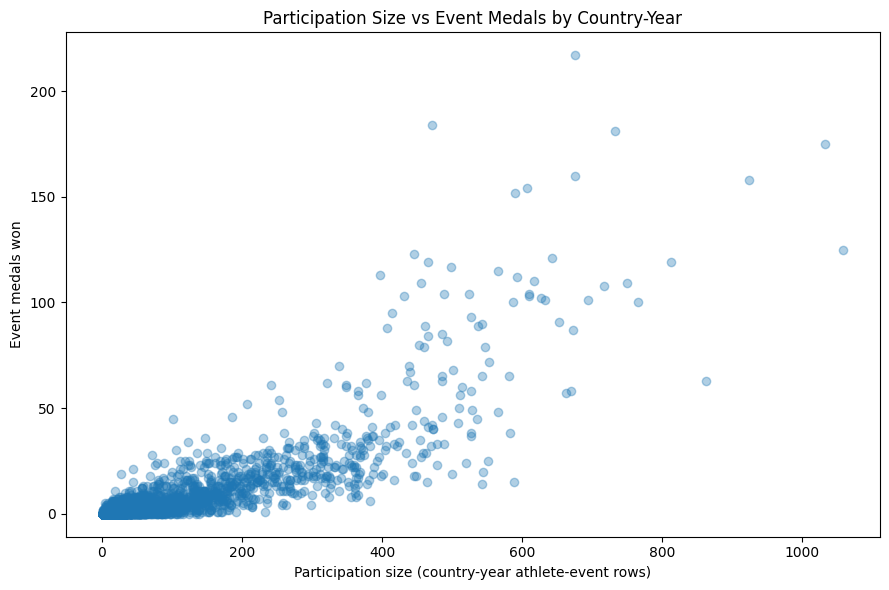

In [88]:
plt.figure(figsize=(9,6))
plt.scatter(
    sq1["participation_size"],
    sq1["event_medals"],
    alpha=0.35
)

plt.title("Participation Size vs Event Medals by Country-Year")
plt.xlabel("Participation size (country-year athlete-event rows)")
plt.ylabel("Event medals won")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ1_plot1_scatter_participation_vs_event_medals.png", dpi=300)
plt.show()


### RQ2-SQ1-4: Simple linear regression helpers 


In [89]:
def standard_units(x):
    return (x - np.mean(x)) / np.std(x)

def correlation(x, y):
    return np.mean(standard_units(x) * standard_units(y))

def slope(x, y):
    return correlation(x, y) * np.std(y) / np.std(x)

def intercept(x, y):
    return np.mean(y) - slope(x, y) * np.mean(x)

def fit_least_squares(x, y):
    theta_0 = intercept(x, y)
    theta_1 = slope(x, y)
    return theta_0, theta_1

def predict(x, theta_0, theta_1):
    return theta_0 + theta_1 * x

def compute_mse(y, yhat):
    return np.mean((y - yhat) ** 2)


### RQ2-SQ1-5: Fit the simple linear regression model
We model:

\[
\text{event\_medals} = \theta_0 + \theta_1(\text{participation\_size})
\]

A positive slope would support the idea that larger delegations tend to win more medals.


In [90]:
x = sq1["participation_size"].to_numpy()
y = sq1["event_medals"].to_numpy()

theta_0, theta_1 = fit_least_squares(x, y)
yhat = predict(x, theta_0, theta_1)

print(f"x_mean : {np.mean(x):.2f}, y_mean : {np.mean(y):.2f}")
print(f"x_stdev: {np.std(x):.2f}, y_stdev: {np.std(y):.2f}")
print(f"r = Correlation(x, y): {correlation(x, y):.3f}")
print(f"theta_0: {theta_0:.3f}, theta_1: {theta_1:.3f}")
print(f"RMSE: {np.sqrt(compute_mse(y, yhat)):.3f}")


x_mean : 72.90, y_mean : 6.00
x_stdev: 119.14, y_stdev: 16.06
r = Correlation(x, y): 0.837
theta_0: -2.224, theta_1: 0.113
RMSE: 8.797


## SQ1 Plot 2: Scatterplot with least-squares regression line
This plot shows both the raw relationship and the fitted linear trend.


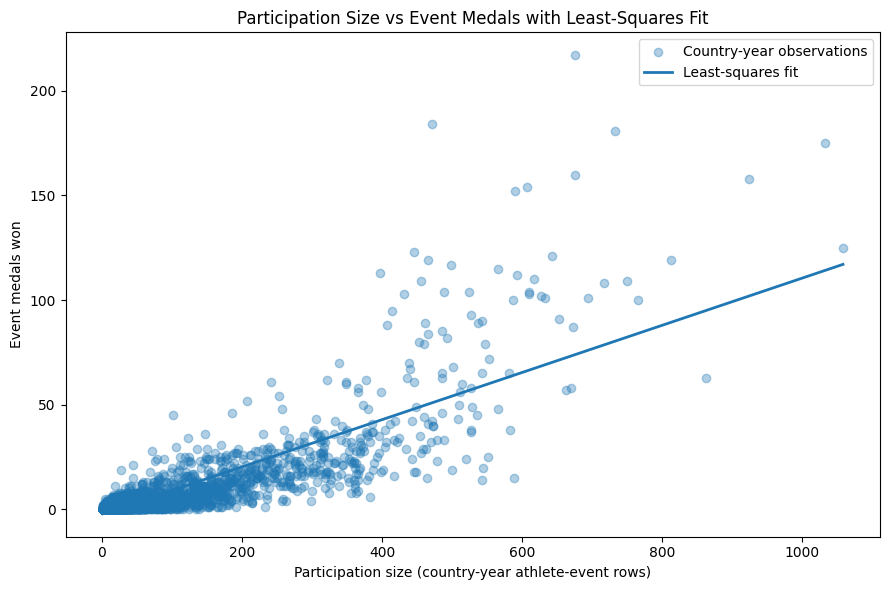

In [91]:
order = np.argsort(x)
x_sorted = x[order]
yhat_sorted = yhat[order]

plt.figure(figsize=(9,6))
plt.scatter(x, y, alpha=0.35, label="Country-year observations")
plt.plot(x_sorted, yhat_sorted, linewidth=2, label="Least-squares fit")

plt.title("Participation Size vs Event Medals with Least-Squares Fit")
plt.xlabel("Participation size (country-year athlete-event rows)")
plt.ylabel("Event medals won")
plt.legend()
plt.tight_layout()
plt.savefig("figures/RQ2_SQ1_plot2_scatter_with_regression_line.png", dpi=300)
plt.show()


This plot had data points that were too densely clustered, making it difficult to clearly see the relationship between the variables. To address this, we applied a log transformation to the variables.

A slightly more polished version:

The data points in this plot were too densely packed, which made the relationship between the variables difficult to interpret. To improve visibility and reveal the pattern more clearly, we applied a log transformation to the variables.

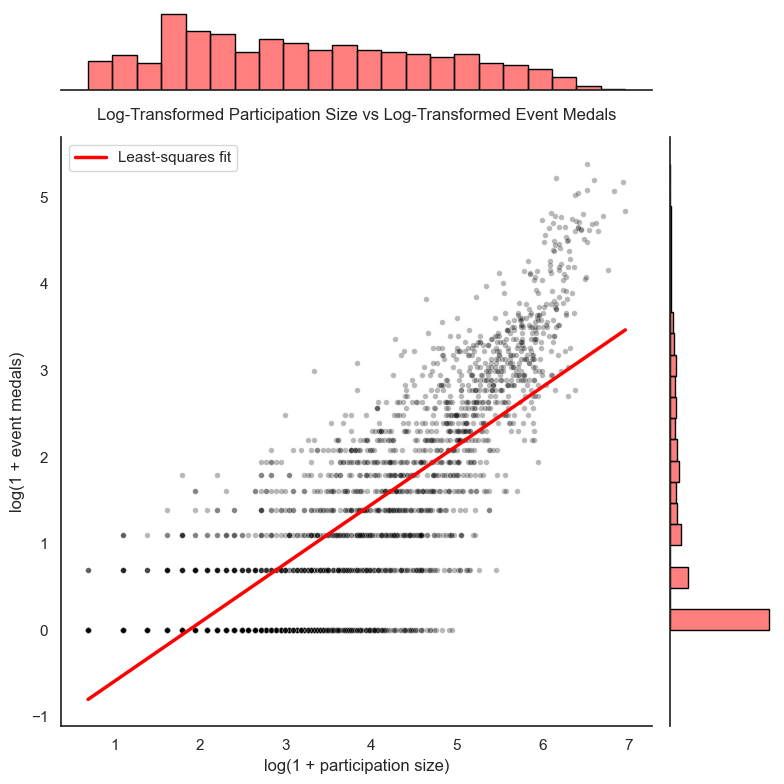

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")

sq1["log_participation_size"] = np.log1p(sq1["participation_size"])
sq1["log_event_medals"] = np.log1p(sq1["event_medals"])

x = sq1["log_participation_size"].to_numpy()
y = sq1["log_event_medals"].to_numpy()

theta_1 = np.corrcoef(x, y)[0, 1] * np.std(y) / np.std(x)
theta_0 = np.mean(y) - theta_1 * np.mean(x)
yhat = theta_0 + theta_1 * x

order = np.argsort(x)

g = sns.jointplot(
    x=x,
    y=y,
    kind="scatter",
    height=8,
    space=0,
    color="#000000",
    joint_kws={
        "s": 16,
        "alpha": 0.28
    },
    marginal_kws={
        "bins": 22,
        "fill": True,
        "alpha": 0.5,
        "color": "red",
        "edgecolor": "#000000"
    }
)

g.ax_joint.plot(
    x[order],
    yhat[order],
    color="red",
    linewidth=2.5,
    label="Least-squares fit"
)

g.ax_joint.set_xlabel("log(1 + participation size)")
g.ax_joint.set_ylabel("log(1 + event medals)")
g.ax_joint.set_title(
    "Log-Transformed Participation Size vs Log-Transformed Event Medals",
    pad=12
)

g.ax_joint.legend()
plt.tight_layout()
plt.show()

## SQa Plot 3: Residual plot
Residuals help check whether a straight-line model is reasonable.  
If the residuals are randomly scattered around zero, the linear model is more appropriate.  
If there is a curve or funnel shape, the relationship may not be fully linear.


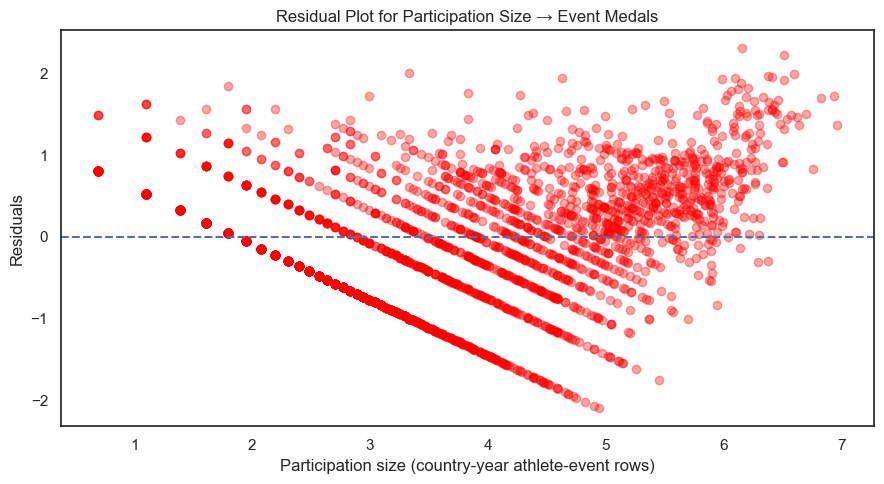

In [93]:
residuals = y - yhat

plt.figure(figsize=(9,5))
plt.scatter(x, residuals, alpha=0.35, color="red")
plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot for Participation Size → Event Medals")
plt.xlabel("Participation size (country-year athlete-event rows)")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ1_plot3_residuals.png", dpi=300)
plt.show()


We initially used a simple linear regression to examine the relationship between participation size and event medals, since it provided a straightforward way to test whether larger delegations tend to win more medals. While the model showed a positive overall association, the scatterplot and residual patterns indicated that the fit was not very good. The relationship was not fully linear, and the simple model could not account for much of the variation in medal outcomes across country-years. Because of this, we moved to a multiple regression model, which allows us to include additional predictors such as the number of sports and year. This gives a more realistic view of Olympic success by recognizing that medal outcomes depend on more than participation size alone.

MULTIPLE REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:       log_event_medals   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     3200.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:47:51   Log-Likelihood:                -3197.0
No. Observations:                3376   AIC:                             6402.
Df Residuals:                    3372   BIC:                             6426.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------


,Variable,Coefficient,P_value
0,const,8.517717,1.115049e-28
1,log_participation_size,0.340070,4.890049e-99
2,num_sports,0.067958,1.840913e-120
3,year,-0.004664,2.361353e-34


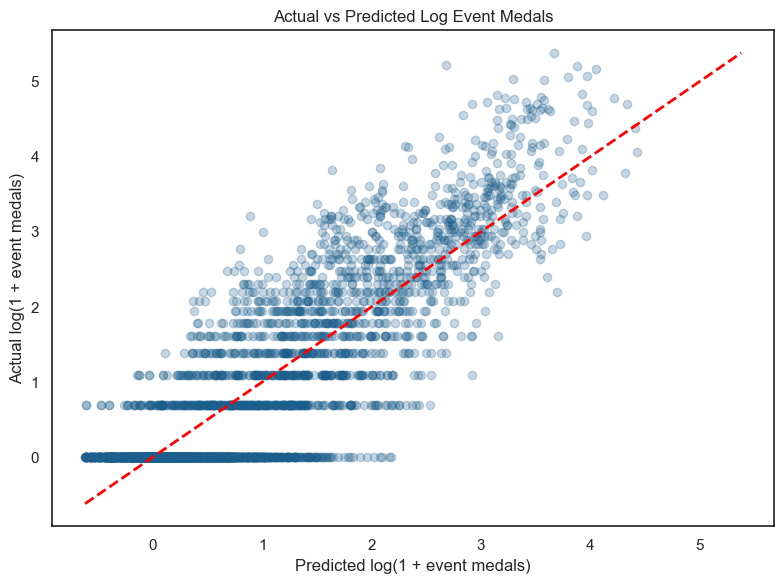

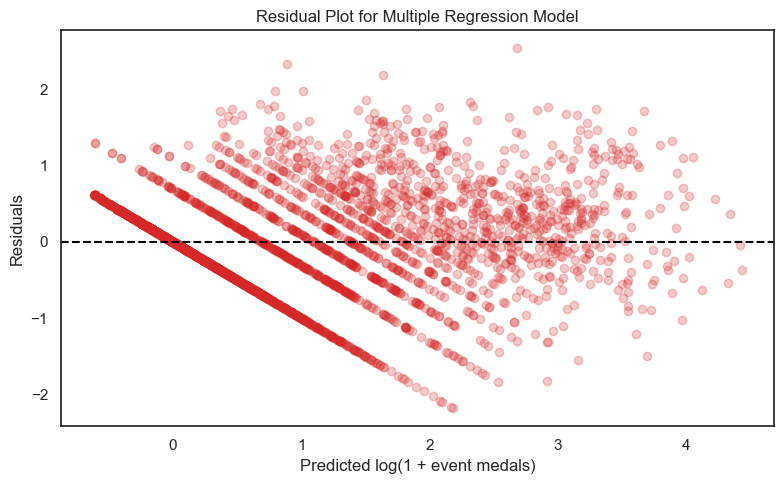

,year,team_clean,participation_size,event_medals,num_sports,log_participation_size,log_event_medals,pred_log_event_medals,residuals_multi
0,1896,Australia,4,2,2,1.609438,1.098612,0.357325,0.741287
1,1896,Austria,8,5,3,2.197225,1.791759,0.625172,1.166588
2,1896,Denmark,15,6,5,2.772589,1.945910,0.956752,0.989158
3,1896,France,19,11,4,2.995732,2.484907,0.964678,1.520228
4,1896,Germany,64,13,6,4.174387,2.639057,1.501420,1.137637
5,1896,Greece,16,7,5,2.833213,2.079442,0.977369,1.102073
6,1896,Hungary,14,6,6,2.708050,1.945910,1.002763,0.943147
7,1896,Sweden,5,0,2,1.791759,0.000000,0.419327,-0.419327
8,1896,Switzerland,4,3,1,1.609438,1.386294,0.289367,1.096928
9,1896,United Kingdom,17,6,7,2.890372,1.945910,1.132723,0.813187


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


# Build num_sports at the country-year level

num_sports_cy = (
    df_sq1.groupby(["year", "team_clean"])["sports"]
    .nunique()
    .rename("num_sports")
    .reset_index()
)

# Merge into sq1 if not already present
sq1 = sq1.drop(columns=["num_sports"], errors="ignore").merge(
    num_sports_cy,
    on=["year", "team_clean"],
    how="left"
)

sq1["num_sports"] = sq1["num_sports"].fillna(0).astype(int)


# Transform variables

sq1["log_participation_size"] = np.log1p(sq1["participation_size"])
sq1["log_event_medals"] = np.log1p(sq1["event_medals"])


# Multiple regression
# Response: log_event_medals
# Predictors: log_participation_size, num_sports, year

y = sq1["log_event_medals"]
X = sq1[["log_participation_size", "num_sports", "year"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print("MULTIPLE REGRESSION SUMMARY")
print(model.summary())


# Predictions and residuals

sq1["pred_log_event_medals"] = model.predict(X)
sq1["residuals_multi"] = sq1["log_event_medals"] - sq1["pred_log_event_medals"]


# Compare against simple regression

X_simple = sm.add_constant(sq1[["log_participation_size"]])
model_simple = sm.OLS(y, X_simple).fit()

print("\nMODEL COMPARISON")
print(f"Simple regression R-squared:   {model_simple.rsquared:.4f}")
print(f"Multiple regression R-squared: {model.rsquared:.4f}")


# Coefficient table

coef_table = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "P_value": model.pvalues.values
})

print("\nCOEFFICIENT TABLE")
display(coef_table)


# Actual vs Predicted Plot

plt.figure(figsize=(8,6))
plt.scatter(
    sq1["pred_log_event_medals"],
    sq1["log_event_medals"],
    alpha=0.25,
    color="#1D5F8C"
)

min_val = min(sq1["pred_log_event_medals"].min(), sq1["log_event_medals"].min())
max_val = max(sq1["pred_log_event_medals"].max(), sq1["log_event_medals"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2)

plt.title("Actual vs Predicted Log Event Medals")
plt.xlabel("Predicted log(1 + event medals)")
plt.ylabel("Actual log(1 + event medals)")
plt.tight_layout()
plt.show()


# Residual Plot

plt.figure(figsize=(8,5))
plt.scatter(
    sq1["pred_log_event_medals"],
    sq1["residuals_multi"],
    alpha=0.25,
    color="#D62828"
)
plt.axhline(0, color="black", linestyle="--")

plt.title("Residual Plot for Multiple Regression Model")
plt.xlabel("Predicted log(1 + event medals)")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()


# Preview useful output

display(
    sq1[[
        "year", "team_clean", "participation_size", "event_medals",
        "num_sports", "log_participation_size", "log_event_medals",
        "pred_log_event_medals", "residuals_multi"
    ]].head(10)
)

## Conclusion

Participation size is positively associated with Olympic medal success: countries with larger delegations generally win more event medals. The multiple regression model fits better than the simple regression, showing that medal outcomes are also influenced by factors like participation across more sports and time. Still, the residual patterns suggest the model does not capture all the complexity, so delegation size is an important predictor, but not a complete explanation of Olympic dominance.

## SQb (Efficiency): Which countries are the most efficient at converting participation into medals?

This sub-question examines which countries convert Olympic participation into medal success most efficiently.  
Because the dataset does not include a unique athlete identifier, we use **participation size** as a proxy for delegation scale, measured by the number of athlete-event rows for each country.

To avoid overcounting team events, medal counts are measured using the **event-medal method**, where each country-event medal is counted once.

Efficiency is defined as:

$$
\text{efficiency} = \frac{\text{event medals}}{\text{participation size}}
$$

For readability, this is also expressed as **event medals per 100 entries**.

This section uses:
- **Plot 1:** Top countries by medal efficiency
- **Plot 2:** Participation size vs event medals, with highly efficient countries highlighted
- **Plot 3:** Actual minus predicted medals (overperformance relative to the SQ1 regression model)

The goal is to identify countries that achieve unusually strong medal outcomes relative to the scale of their Olympic participation.

Top 25 countries by medal efficiency (minimum 100 participation rows):


,team_clean,participation_size,event_medals,num_sports,event_medals_per_100_entries
0,Russia,10042,1873,66,18.651663
1,United States,16681,2939,79,17.618848
2,Azerbaijan,383,59,28,15.404700
3,Ethiopia,408,61,7,14.950980
4,Kenya,801,116,18,14.481898
5,China,5171,740,65,14.310578
6,Georgia,356,49,28,13.764045
7,Germany,14396,1819,72,12.635454
8,Norway,4492,482,52,10.730187
9,Cuba,2221,237,32,10.670869


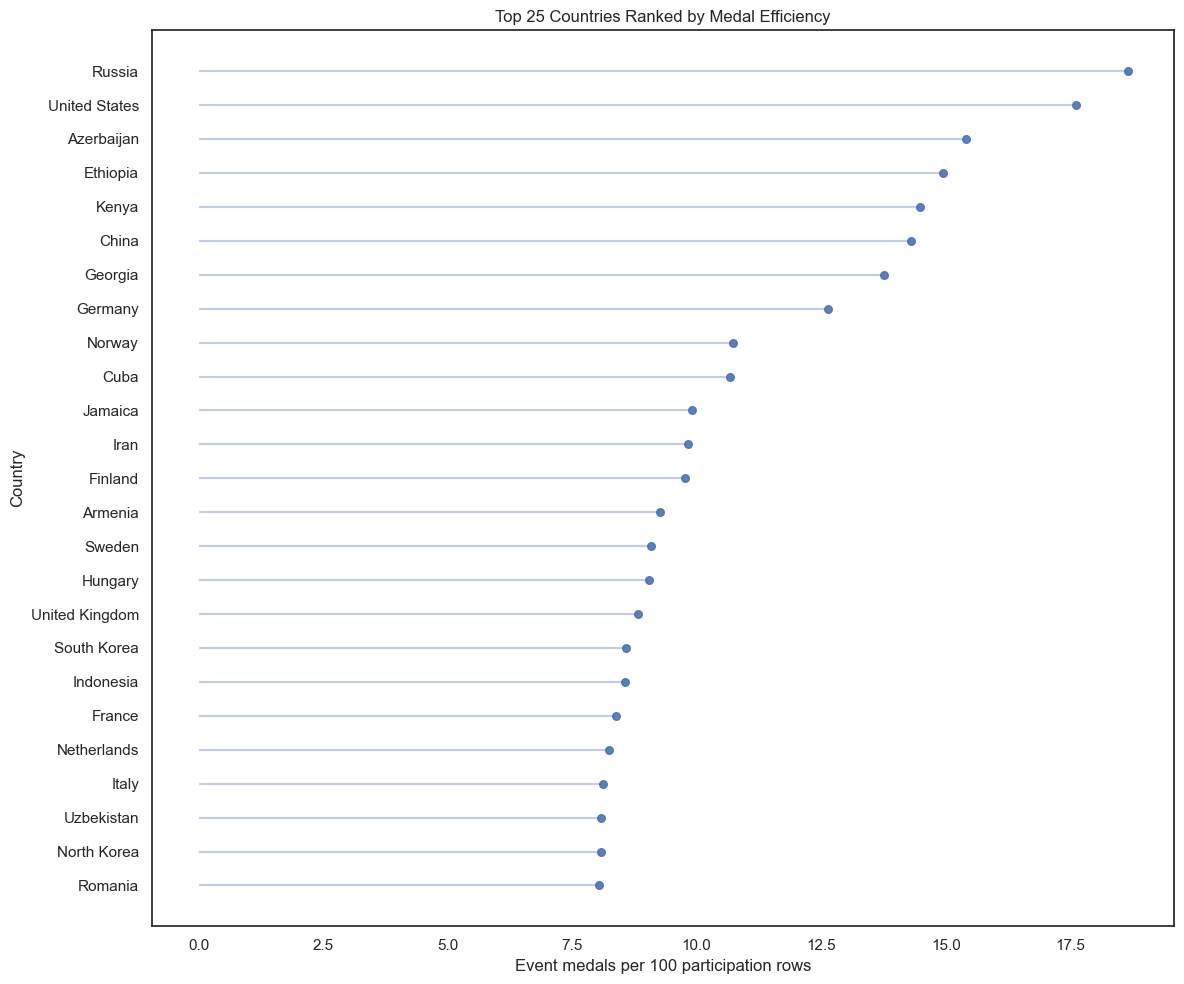

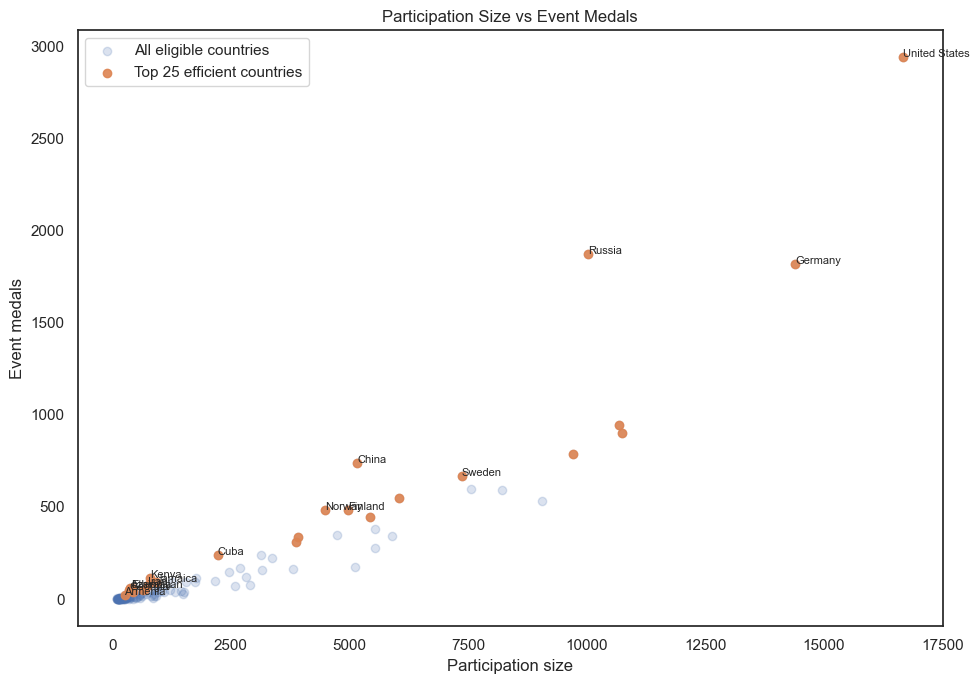

In [95]:
# Setup
os.makedirs("outputs", exist_ok=True)

required_cols = {"team_clean", "year", "event", "medal", "sports"}
missing_cols = required_cols - set(df.columns)

if missing_cols:
    raise ValueError(f"df is missing required columns: {missing_cols}")

top_n = 25

# SQB: Build country-level efficiency table from cleaned df

medalists = df[df["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

event_medals_df = medalists.drop_duplicates(
    subset=["year", "event", "team_clean", "medal"]
).copy()

country_entries = (
    df.groupby("team_clean")
    .size()
    .rename("participation_size")
)

country_event_medals = (
    event_medals_df.groupby("team_clean")
    .size()
    .rename("event_medals")
)

country_num_sports = (
    df.groupby("team_clean")["sports"]
    .nunique()
    .rename("num_sports")
)

efficiency_df = pd.concat(
    [country_entries, country_event_medals, country_num_sports],
    axis=1
).fillna(0).reset_index()

efficiency_df["event_medals"] = efficiency_df["event_medals"].astype(int)
efficiency_df["num_sports"] = efficiency_df["num_sports"].astype(int)

efficiency_df["efficiency"] = (
    efficiency_df["event_medals"] / efficiency_df["participation_size"]
)
efficiency_df["event_medals_per_100_entries"] = efficiency_df["efficiency"] * 100

 
# Filter out tiny countries

min_entries = 100
efficiency_filtered = efficiency_df[
    efficiency_df["participation_size"] >= min_entries
].copy()

all_eff = efficiency_filtered.sort_values(
    "event_medals_per_100_entries", ascending=False
).reset_index(drop=True)

top_eff = all_eff.head(top_n).copy()

print(f"Top {top_n} countries by medal efficiency (minimum {min_entries} participation rows):")
try:
    display(
        top_eff[[
            "team_clean", "participation_size", "event_medals",
            "num_sports", "event_medals_per_100_entries"
        ]]
    )
except NameError:
    print(
        top_eff[[
            "team_clean", "participation_size", "event_medals",
            "num_sports", "event_medals_per_100_entries"
        ]].to_string(index=False)
    )

# Plot 1: Horizontal dot/lollipop plot for top 25 countries

plt.figure(figsize=(12, max(10, len(top_eff) * 0.28)))
y_pos = np.arange(len(top_eff))

plt.hlines(
    y=y_pos,
    xmin=0,
    xmax=top_eff["event_medals_per_100_entries"],
    alpha=0.35
)
plt.scatter(
    top_eff["event_medals_per_100_entries"],
    y_pos,
    s=30,
    alpha=0.9
)

plt.yticks(y_pos, top_eff["team_clean"])
plt.gca().invert_yaxis()
plt.title(f"Top {top_n} Countries Ranked by Medal Efficiency")
plt.xlabel("Event medals per 100 participation rows")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Plot 2: Participation size vs event medals
# Highlight top 25 efficient countries

plt.figure(figsize=(10, 7))
plt.scatter(
    efficiency_filtered["participation_size"],
    efficiency_filtered["event_medals"],
    alpha=0.20,
    label="All eligible countries"
)

plt.scatter(
    top_eff["participation_size"],
    top_eff["event_medals"],
    alpha=0.9,
    label=f"Top {top_n} efficient countries"
)

# Labeling only top 15 to avoid clutter
for _, row in top_eff.head(15).iterrows():
    plt.text(
        row["participation_size"],
        row["event_medals"],
        row["team_clean"],
        fontsize=8
    )

plt.title("Participation Size vs Event Medals")
plt.xlabel("Participation size")
plt.ylabel("Event medals")
plt.legend()
plt.tight_layout()
plt.show()


## SQc: Which countries dominated the Olympics in the most recent Olympic year in the dataset?



This sub-question examines which countries achieved the strongest Olympic performance in the most recent Olympic year recorded in the dataset.

Dominance is measured primarily using **event-medal counts**, so that each **country-event medal is counted once** and team events are not overcounted.

Because the dataset does not include a unique athlete identifier, **participation size** is used as a proxy for delegation scale, measured by the number of **athlete-event rows** for each country in the most recent Olympic year. This makes it possible to compare raw medal dominance alongside the scale of each country’s Olympic participation.

To avoid overcounting team events, medal counts are measured using the **event-medal method**, where each country-event medal is counted once.

Dominance is assessed using **total medal output** in the most recent Olympic year, while efficiency is measured as:

$$
\text{Efficiency} = \frac{\text{Event medals}}{\text{Participation size}}
$$

For readability, efficiency is also expressed as **event medals per 100 entries**:

$$
\text{Efficiency per 100 entries} = \frac{\text{Event medals}}{\text{Participation size}} \times 100
$$

### This section uses

- **Plot 1:** Top country by event medals in Olympic years from **2000 to 2024**  
  (`2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2020, 2022, 2024`)

### Goal

The goal is to identify which country dominated the most recent Olympic Games in the dataset and to compare **raw medal dominance**, **participation size**, and **medal efficiency**.

    year           team  event_medals
0   2000         Russia            83
1   2002        Germany            30
2   2004  United States            87
3   2006        Germany            25
4   2008  United States            92
5   2010  United States            29
6   2012  United States            91
7   2014         Russia            29
8   2016  United States           107
9   2020  United States            97
10  2022         Canada            15
11  2024  United States            70


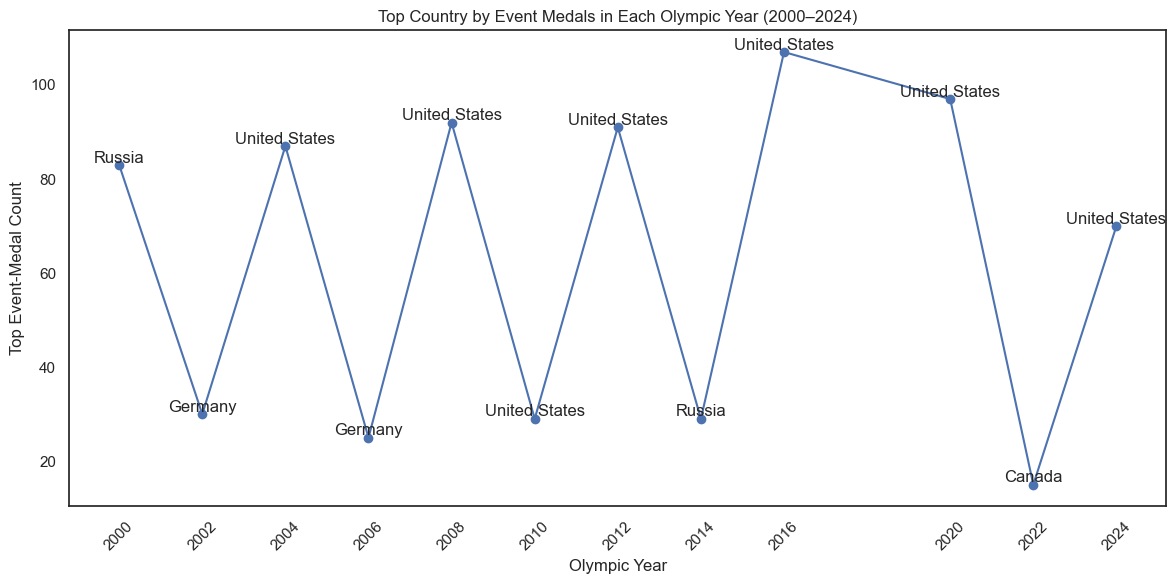

In [98]:

# 1. Keep only 21st century Olympic years

years_21st = [2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2020, 2022, 2024]
df_21 = df[df["year"].isin(years_21st)].copy()


# 2. Count event medals
#    Count each country-event medal once

event_medals = (
    df_21[df_21["medal"].notna()]
    .drop_duplicates(subset=["team", "event", "year"])
    .groupby(["year", "team"])
    .size()
    .rename("event_medals")
    .reset_index()
)


# 3. Find top country in each Olympic year

top_country_each_year = (
    event_medals.sort_values(["year", "event_medals"], ascending=[True, False])
    .groupby("year")
    .first()
    .reset_index()
)

print(top_country_each_year)


# 4. Line plot

plt.figure(figsize=(12, 6))
plt.plot(
    top_country_each_year["year"],
    top_country_each_year["event_medals"],
    marker="o"
)

# Label each point with country
for _, row in top_country_each_year.iterrows():
    plt.text(
        row["year"],
        row["event_medals"] + 0.5,
        row["team"],
        ha="center"
    )

plt.xlabel("Olympic Year")
plt.ylabel("Top Event-Medal Count")
plt.title("Top Country by Event Medals in Each Olympic Year (2000–2024)")
plt.xticks(years_21st, rotation=45)
plt.tight_layout()
plt.show()

A major limitation of the dataset is the missing 2018 Winter Olympics data. Since the analysis covers Olympic years from 2000 to 2024, this creates a gap in the 21st-century timeline and makes the Winter Olympic record incomplete. As a result, trends over time may be less accurate, especially for Winter Games, because the analysis jumps from 2014 directly to 2022.

This also affects conclusions about country dominance. Countries that may have performed strongly in 2018 are completely excluded, while countries dominant in nearby years may appear more consistent than they actually were. Overall, the results are still useful, but they should be interpreted as reflecting the available dataset, not the full Olympic record.

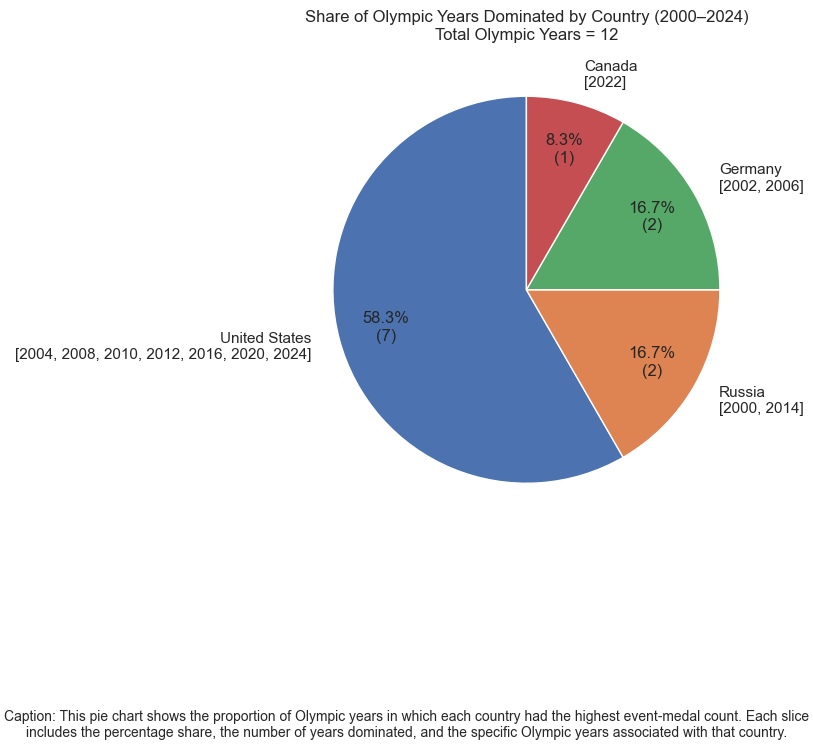

In [102]:
plt.figure(figsize=(8, 8))

# Count how many Olympic years each country dominated
dominance_counts = top_country_each_year["team"].value_counts()

# Total number of Olympic years in the analysis
total_years = len(top_country_each_year)

# Build a dictionary: country -> list of years dominated
country_years = (
    top_country_each_year.groupby("team")["year"]
    .apply(list)
    .to_dict()
)

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})"
    return my_autopct

# Labels include country + exact years dominated
pie_labels = [
    f"{country}\n{country_years[country]}"
    for country in dominance_counts.index
]

plt.pie(
    dominance_counts.values,
    labels=pie_labels,
    autopct=make_autopct(dominance_counts.values),
    startangle=90,
    labeldistance=1.15,
    pctdistance=0.75
)

plt.title(
    f"Share of Olympic Years Dominated by Country (2000–2024)\n"
    f"Total Olympic Years = {total_years}"
)

plt.figtext(
    0.5, -0.08,
    "Caption: This pie chart shows the proportion of Olympic years in which each country had the highest event-medal count. "
    "Each slice includes the percentage share, the number of years dominated, and the specific Olympic years associated with that country.",
    ha="center",
    fontsize=10,
    wrap=True
)

plt.tight_layout()
plt.show()